In [6]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

import torch
from torchsurv.loss.weibull import survival_function

In [7]:
data_path = r'D:\python文件\ViT3D_Inference\data5\test\preprocessed'
result_path = r'results'

label_df_path = r'D:\python文件\ViT3D_Inference\data5\test_label.csv'
label_df = pd.read_csv(label_df_path)
variable_list = ['sex', 'age', 'who_grade', 'group', 'gbl', 'idh', '_1p19q', 'mgmt', 'eor_op1', 'kps', 'radiotherapy1', 'chemotherapy1', 'death_event', 'death_duration', 'death_duration_month']
for variable in variable_list:
    label_df = label_df[label_df[variable].notna()]

label_df['patient_id'] = label_df['patient_id'].astype(str)
patient_list = [f"{row['patient_id']}" for _, row in label_df.iterrows()]
print(label_df)
print(f"Number of patients: {len(patient_list)}")

  patient_id  sex  age  who_grade  group  gbl  idh  _1p19q  mgmt  kps  \
0         C1   -1   -1         -1     -1   -1   -1      -1    -1   -1   
1         C2   -1   -1         -1     -1   -1   -1      -1    -1   -1   

   eor_op1  radiotherapy1  chemotherapy1  death_event  death_duration  \
0       -1             -1             -1            1              -1   
1       -1             -1             -1            0              -1   

   death_duration_month  
0                    14  
1                    14  
Number of patients: 2


Starting visualization. Total patients: 2
Data path: D:\python文件\ViT3D_Inference\data5\test\preprocessed
Result path: results

[1/2] Processing patient: C1
  Checking result file: results/C1.npy
  ✓ Loaded result file
    ✓ Using tumor mask: tumor_mask.nii.gz
    ✓ Resampled vision_cam to (364, 436, 364)
  ✓ Loaded MRI images via nibabel (with fallbacks)
  ✓ Preprocessed images, slice index: 206


C:\Users\jzk\AppData\Local\Temp\ipykernel_23668\1958978177.py:182: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  prob_at_duration = estimates[torch.argmin(torch.abs(new_times - duration))].item()


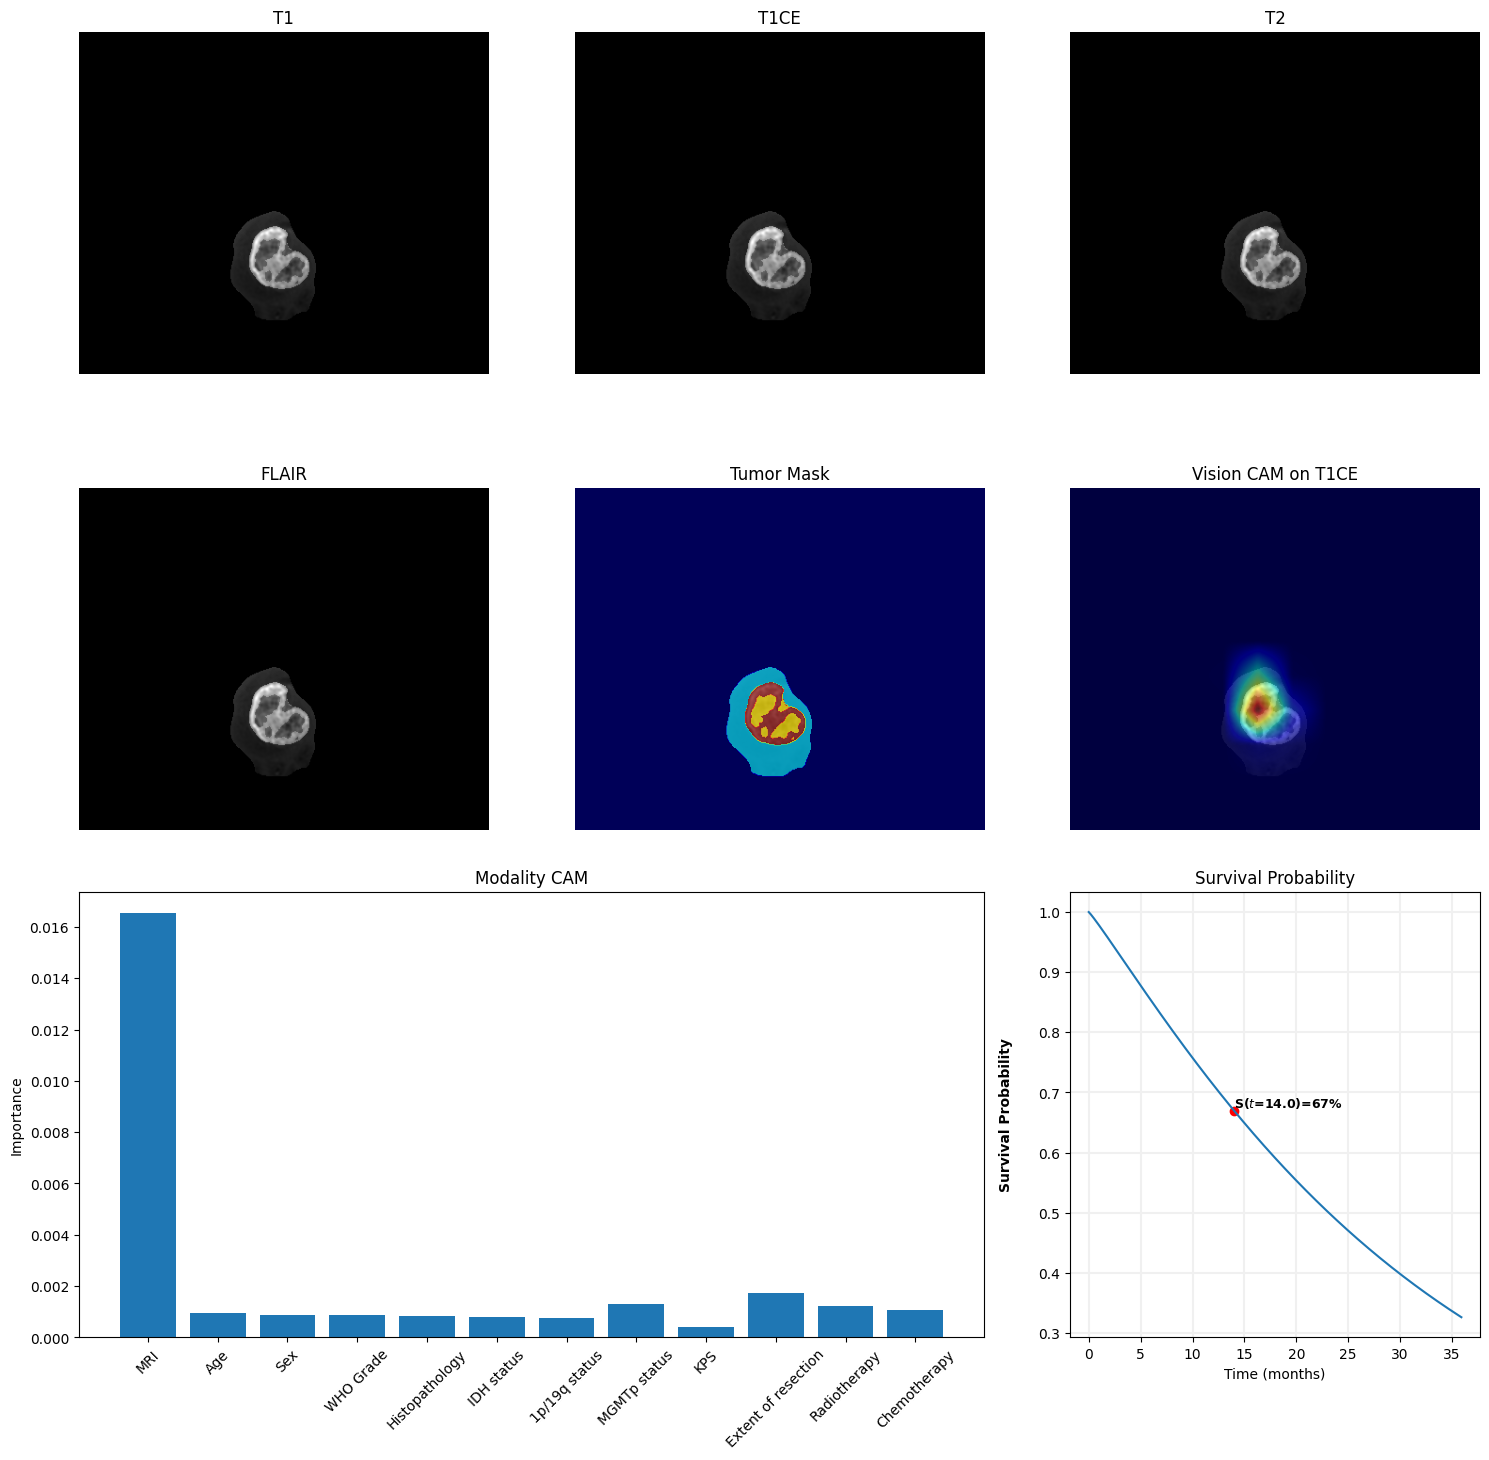

  ✓ Successfully displayed patient C1

[2/2] Processing patient: C2
  Checking result file: results/C2.npy
  ✓ Loaded result file
    ✓ Using tumor mask: tumor_mask.nii.gz
    ✓ Resampled vision_cam to (364, 436, 364)
  ✓ Loaded MRI images via nibabel (with fallbacks)
  ✓ Preprocessed images, slice index: 161


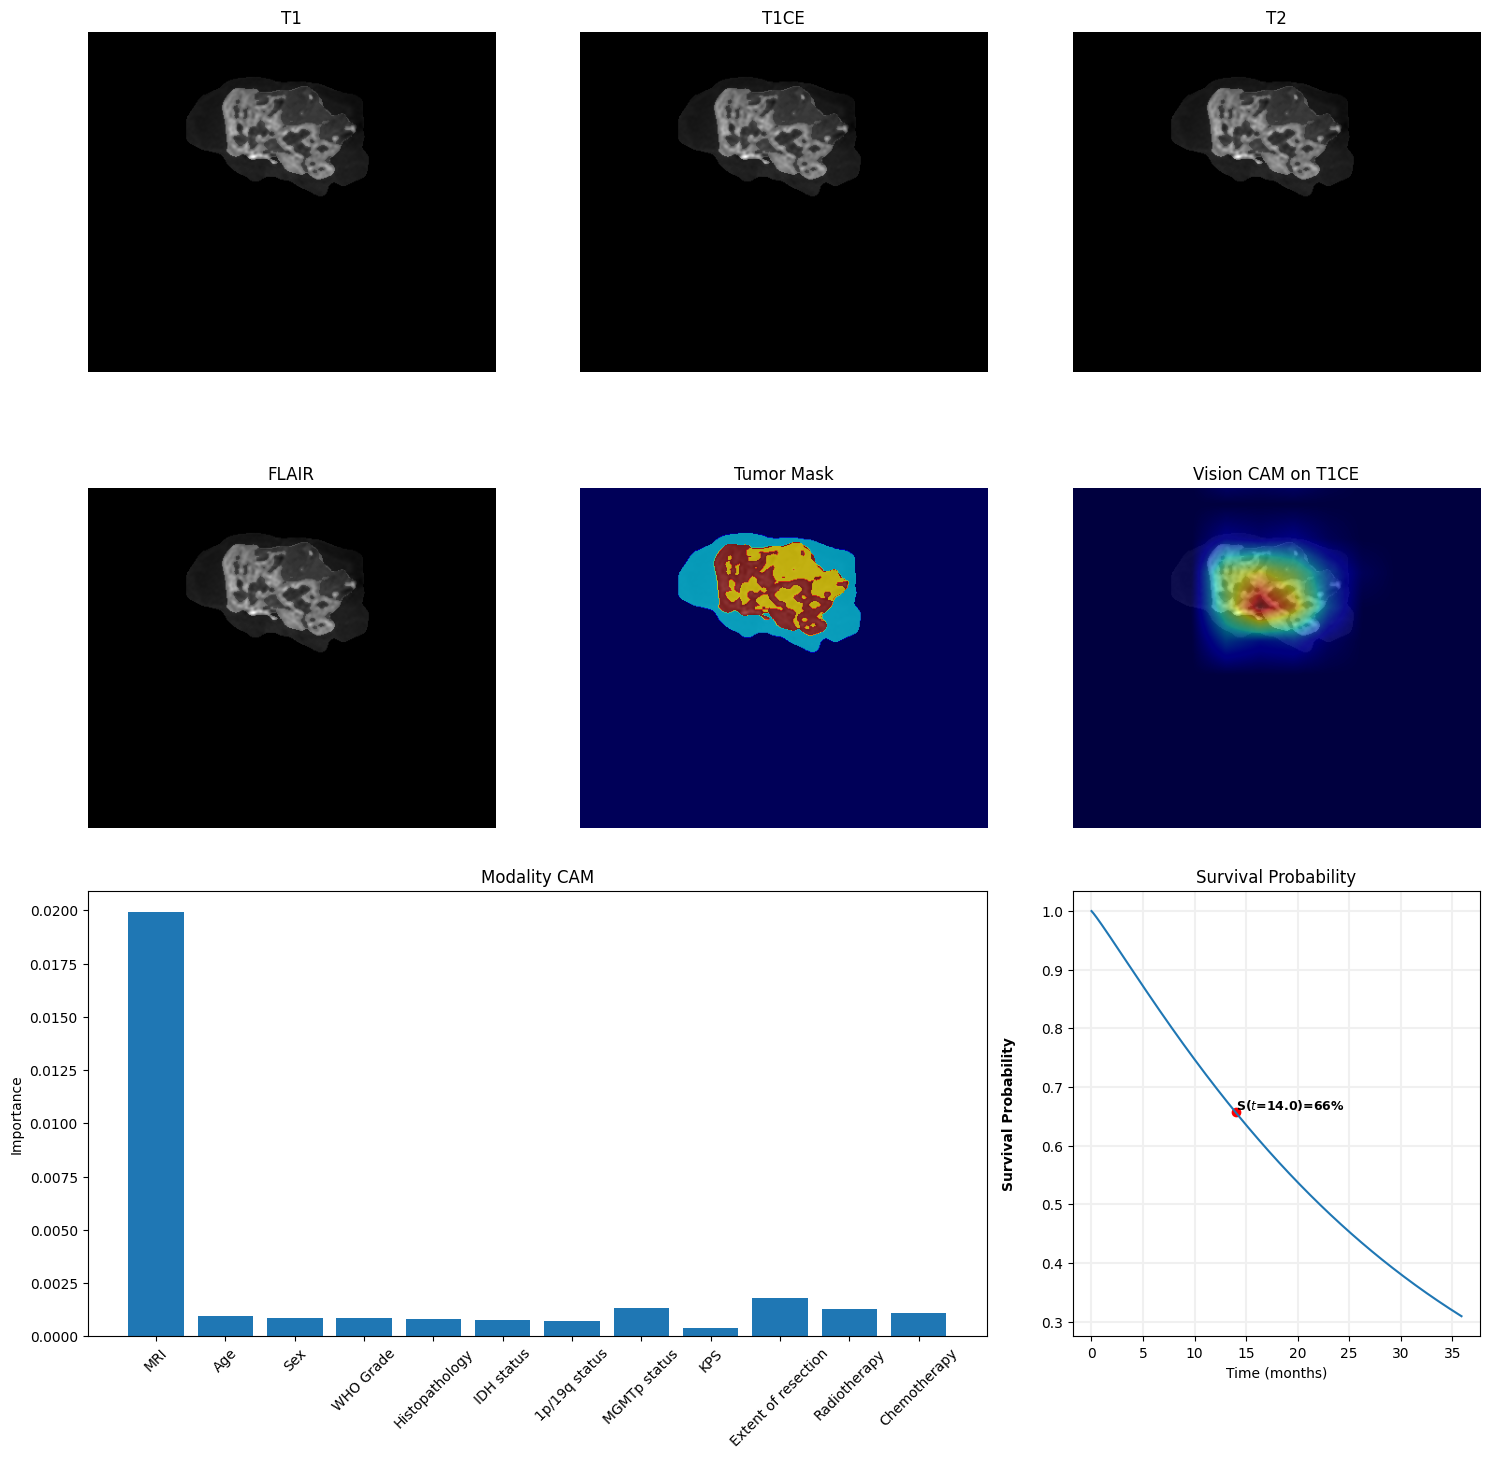

  ✓ Successfully displayed patient C2

========== DONE ==========
Successfully visualized 2/2 patients


In [8]:

new_times = torch.arange(0, 36, 0.1)
select_indices = [4, 5, 8, 9, 11]
full_feature_names = ['MRI', 'Age', 'Sex', 'WHO Grade', 'Histopathology', 'IDH status', '1p/19q status', 'MGMTp status', 'KPS', 'Extent of resection', 'Radiotherapy', 'Chemotherapy']

print(f"Starting visualization. Total patients: {len(patient_list)}")
print(f"Data path: {data_path}")
print(f"Result path: {result_path}")

count = 0
for idx, patient_id in enumerate(patient_list):
    print(f"\n[{idx+1}/{len(patient_list)}] Processing patient: {patient_id}")
    try:
        data_dir = f'{data_path}/{patient_id}'
        t1_path = f'{data_dir}/t1.nii.gz'
        t1ce_path = f'{data_dir}/t1ce.nii.gz'
        t2_path = f'{data_dir}/t2.nii.gz'
        flair_path = f'{data_dir}/flair.nii.gz'
        brain_mask_path = f'{data_dir}/brain_mask.nii.gz'
        WT_tumor_mask_path = f'{data_dir}/WT_tumor_mask.nii.gz'
        
        result_file = f'{result_path}/{patient_id}.npy'
        print(f"  Checking result file: {result_file}")
        
        if not os.path.exists(result_file):
            print(f"  ⚠️  SKIP: Result file not found")
            continue
            
        result = np.load(result_file, allow_pickle=True).item()
        vision_cam = result.get('vision_cam')
        print(f"  ✓ Loaded result file")
        
        # 先保证 t1 可读取，用于确定形状作 fallback
        if not os.path.exists(t1_path):
            print(f"  ✗ Missing t1 image for {patient_id}, skipping")
            continue
        t1_img = nib.load(t1_path)
        t1_numpy = t1_img.get_fdata().astype(np.float32)

        def load_or_zeros(path, shape, name=None):
            if os.path.exists(path):
                try:
                    return nib.load(path).get_fdata().astype(np.float32)
                except Exception as e:
                    print(f"    ⚠️ Failed to load {name or path}: {e}, using zeros")
                    return np.zeros(shape, dtype=np.float32)
            else:
                print(f"    ⚠️ {name or path} not found, using zeros")
                return np.zeros(shape, dtype=np.float32)

        t1ce_numpy = load_or_zeros(t1ce_path, t1_numpy.shape, 'T1CE')
        t2_numpy = load_or_zeros(t2_path, t1_numpy.shape, 'T2')
        flair_numpy = load_or_zeros(flair_path, t1_numpy.shape, 'FLAIR')
        brain_mask_numpy = load_or_zeros(brain_mask_path, t1_numpy.shape, 'Brain mask')

        # tumor mask: 尝试多个候选路径
        mask_candidates = [WT_tumor_mask_path, os.path.join(data_dir, 'tumor_mask.nii.gz'), os.path.join(data_dir, 'NE_tumor_mask.nii.gz'), os.path.join(data_dir, 'CE_tumor_mask.nii.gz')]
        tumor_mask_numpy = None
        for p in mask_candidates:
            if os.path.exists(p):
                try:
                    tumor_mask_numpy = nib.load(p).get_fdata().astype(np.float32)
                    print(f"    ✓ Using tumor mask: {os.path.basename(p)}")
                    break
                except Exception as e:
                    print(f"    ⚠️ Failed to load mask {p}: {e}")
        if tumor_mask_numpy is None:
            print(f"    ⚠️ No tumor mask found for {patient_id}, using empty mask")
            tumor_mask_numpy = np.zeros(t1_numpy.shape, dtype=np.float32)

        # 如果 mask 与 t1 尺寸不一致，重采样 mask 到 t1 的形状（mask 用最近邻）
        if tumor_mask_numpy.shape != t1_numpy.shape:
            try:
                factors = np.array(t1_numpy.shape) / np.array(tumor_mask_numpy.shape)
                tumor_mask_numpy = zoom(tumor_mask_numpy, factors, order=0)
                print(f"    ✓ Resampled tumor mask from {p} to {t1_numpy.shape}")
            except Exception as e:
                print(f"    ⚠️ Failed to resample tumor mask: {e}, using zeros")
                tumor_mask_numpy = np.zeros(t1_numpy.shape, dtype=np.float32)

        # 处理 vision_cam 的尺寸，如果存在则重采样到 t1 形状（浮点用线性插值）
        if vision_cam is not None:
            vision_cam = np.asarray(vision_cam)
            if vision_cam.shape != t1_numpy.shape:
                try:
                    factors_v = np.array(t1_numpy.shape) / np.array(vision_cam.shape)
                    vision_cam = zoom(vision_cam, factors_v, order=1)
                    print(f"    ✓ Resampled vision_cam to {vision_cam.shape}")
                except Exception as e:
                    print(f"    ⚠️ Failed to resample vision_cam: {e}, using zeros")
                    vision_cam = np.zeros(t1_numpy.shape, dtype=np.float32)

        print(f"  ✓ Loaded MRI images via nibabel (with fallbacks)")
        
        # 进一步处理
        t1_numpy = t1_numpy * brain_mask_numpy
        t1ce_numpy = t1ce_numpy * brain_mask_numpy
        t2_numpy = t2_numpy * brain_mask_numpy
        flair_numpy = flair_numpy * brain_mask_numpy
        
        def quantile_denominator(x):
            q = np.quantile(x, 0.99)
            return q if q != 0 else 1.0
        
        t1_numpy = (t1_numpy - 0) / quantile_denominator(t1_numpy)
        t1ce_numpy = (t1ce_numpy - 0) / quantile_denominator(t1ce_numpy)
        t2_numpy = (t2_numpy - 0) / quantile_denominator(t2_numpy)
        flair_numpy = (flair_numpy - 0) / quantile_denominator(flair_numpy)

        tumor_largest_z_index = int(np.argmax(tumor_mask_numpy.sum(axis=(0, 1)))) if tumor_mask_numpy.sum() > 0 else t1_numpy.shape[-1] // 2
        # Clamp index 到有效范围，防止越界
        tumor_largest_z_index = max(0, min(tumor_largest_z_index, t1_numpy.shape[-1] - 1))
        print(f"  ✓ Preprocessed images, slice index: {tumor_largest_z_index}")
        
        t1_slice_numpy = t1_numpy[..., tumor_largest_z_index]
        t1ce_slice_numpy = t1ce_numpy[..., tumor_largest_z_index]
        t2_slice_numpy = t2_numpy[..., tumor_largest_z_index]
        flair_slice_numpy = flair_numpy[..., tumor_largest_z_index]
        brain_mask_slice_numpy = brain_mask_numpy[..., tumor_largest_z_index]
        tumor_mask_slice_numpy = tumor_mask_numpy[..., tumor_largest_z_index]
        vision_cam_slice_numpy = vision_cam[..., tumor_largest_z_index] if vision_cam is not None else np.zeros_like(t1_slice_numpy)
        
        fig = plt.figure(figsize=(15, 15))
        gs = fig.add_gridspec(3, 3)
        
        ax_t1 = fig.add_subplot(gs[0, 0])
        ax_t1ce = fig.add_subplot(gs[0, 1])
        ax_t2 = fig.add_subplot(gs[0, 2])
        ax_flair = fig.add_subplot(gs[1, 0])
        ax_tumor_mask = fig.add_subplot(gs[1, 1])
        ax_vision_cam = fig.add_subplot(gs[1, 2])

        ax_bar = fig.add_subplot(gs[2, 0:2])
        ax_survival = fig.add_subplot(gs[2, 2])

        ax_t1.imshow(t1_slice_numpy, cmap='gray')
        ax_t1.set_title('T1')
        ax_t1.axis('off')
        
        ax_t1ce.imshow(t1ce_slice_numpy, cmap='gray')
        ax_t1ce.set_title('T1CE')
        ax_t1ce.axis('off')
        
        ax_t2.imshow(t2_slice_numpy, cmap='gray')
        ax_t2.set_title('T2')
        ax_t2.axis('off')
        
        ax_flair.imshow(flair_slice_numpy, cmap='gray')
        ax_flair.set_title('FLAIR')
        ax_flair.axis('off')

        ax_tumor_mask.imshow(t1ce_slice_numpy, cmap='gray')
        ax_tumor_mask.imshow(tumor_mask_slice_numpy, cmap='jet', alpha=0.7)
        ax_tumor_mask.set_title('Tumor Mask')
        ax_tumor_mask.axis('off')

        ax_vision_cam.imshow(t1ce_slice_numpy, cmap='gray')
        ax_vision_cam.imshow(vision_cam_slice_numpy, cmap='jet', alpha=0.5)
        ax_vision_cam.set_title('Vision CAM on T1CE')
        ax_vision_cam.axis('off')

        modality_cam = result.get('modality_cam', None)
        if modality_cam is not None:
            modality_cam = modality_cam[1]
            modality_cam = modality_cam[select_indices]
            modality_cam = np.transpose(modality_cam, (2, 0, 1))
            modality_cam = modality_cam[..., 0]
            modality_cam = np.median(modality_cam, axis=-1)
            ax_bar.bar(full_feature_names, modality_cam)
        else:
            ax_bar.text(0.5, 0.5, 'No modality_cam', ha='center')
        ax_bar.set_title('Modality CAM')
        ax_bar.set_ylabel('Importance')
        ax_bar.tick_params(axis='x', rotation=45)

        output = result.get('output', None)
        event = result.get('event', None)
        duration = result.get('duration', None)

        if output is not None and duration is not None:
            patient_outputs = torch.from_numpy(output).unsqueeze(0)
            estimates = [survival_function(patient_outputs, t) for t in new_times]
            prob_at_duration = estimates[torch.argmin(torch.abs(new_times - duration))].item()
            ax_survival.plot(new_times, estimates)
            ax_survival.scatter(duration, prob_at_duration, color='red')
            ax_survival.text(duration, prob_at_duration, r"S($t$={:.1f})={:.0f}%".format(duration, prob_at_duration*100),
                                color='black', va='bottom', ha='left', fontsize=9, fontweight='bold')
        else:
            ax_survival.text(0.5, 0.5, 'No survival data', ha='center')

        ax_survival.set_title('Survival Probability')
        ax_survival.set_xlabel("Time (months)")
        ax_survival.set_ylabel("Survival Probability", labelpad=18, fontsize=10, weight='bold')
        ax_survival.grid(True, which='major', linewidth=1.5, color='#F0F0F0')

        plt.tight_layout()
        plt.show()
        
        count += 1
        print(f"  ✓ Successfully displayed patient {patient_id}")
        
        #break
        
    except Exception as e:
        print(f"  ✗ ERROR: {type(e).__name__}: {str(e)}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n========== DONE ==========")
print(f"Successfully visualized {count}/{len(patient_list)} patients")


In [ ]:
import matplotlib
matplotlib.use('Agg')  # 关键：改用无GUI后端，避免图形渲染崩溃
import matplotlib.pyplot as plt
import numpy as np

# 测试画图
plt.figure()
plt.plot([1,2,3], [4,5,6])
plt.savefig("test_plot.png")  # 不弹出窗口，直接保存图片
print("画图测试成功！")

画图测试成功！
